/var/folders/x3/7mv5980n3c76nxp5jnxzprwh0000gn/T/ipykernel_16724/2651504109.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


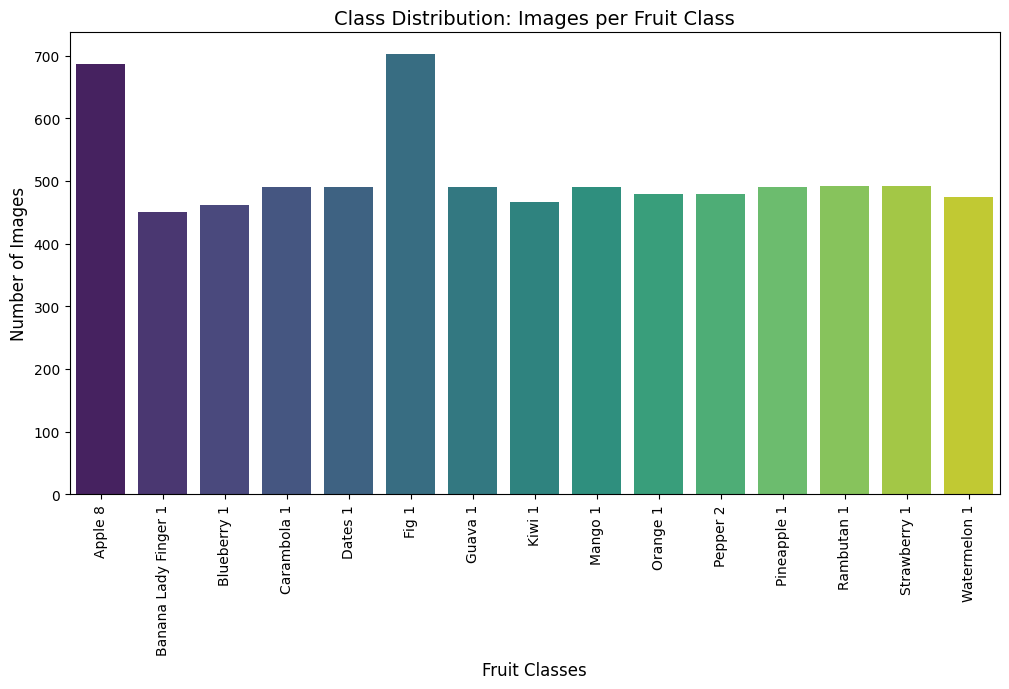

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to your subset directory
data_path = "./fruits-360/Training"
classes = [
    "Apple 8",
    "Banana Lady Finger 1",
    "Blueberry 1",
    "Carambola 1",
    "Dates 1",
    "Fig 1",
    "Guava 1",
    "Kiwi 1",
    "Mango 1",
    "Orange 1",
    "Pepper 2",
    "Pineapple 1",
    "Rambutan 1",
    "Strawberry 1",
    "Watermelon 1",
]

counts = {}
for fruit in classes:
    fruit_dir = os.path.join(data_path, fruit)
    counts[fruit] = len(os.listdir(fruit_dir))

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
plt.title("Class Distribution: Images per Fruit Class", fontsize=14)
plt.xlabel("Fruit Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=90)
plt.show()


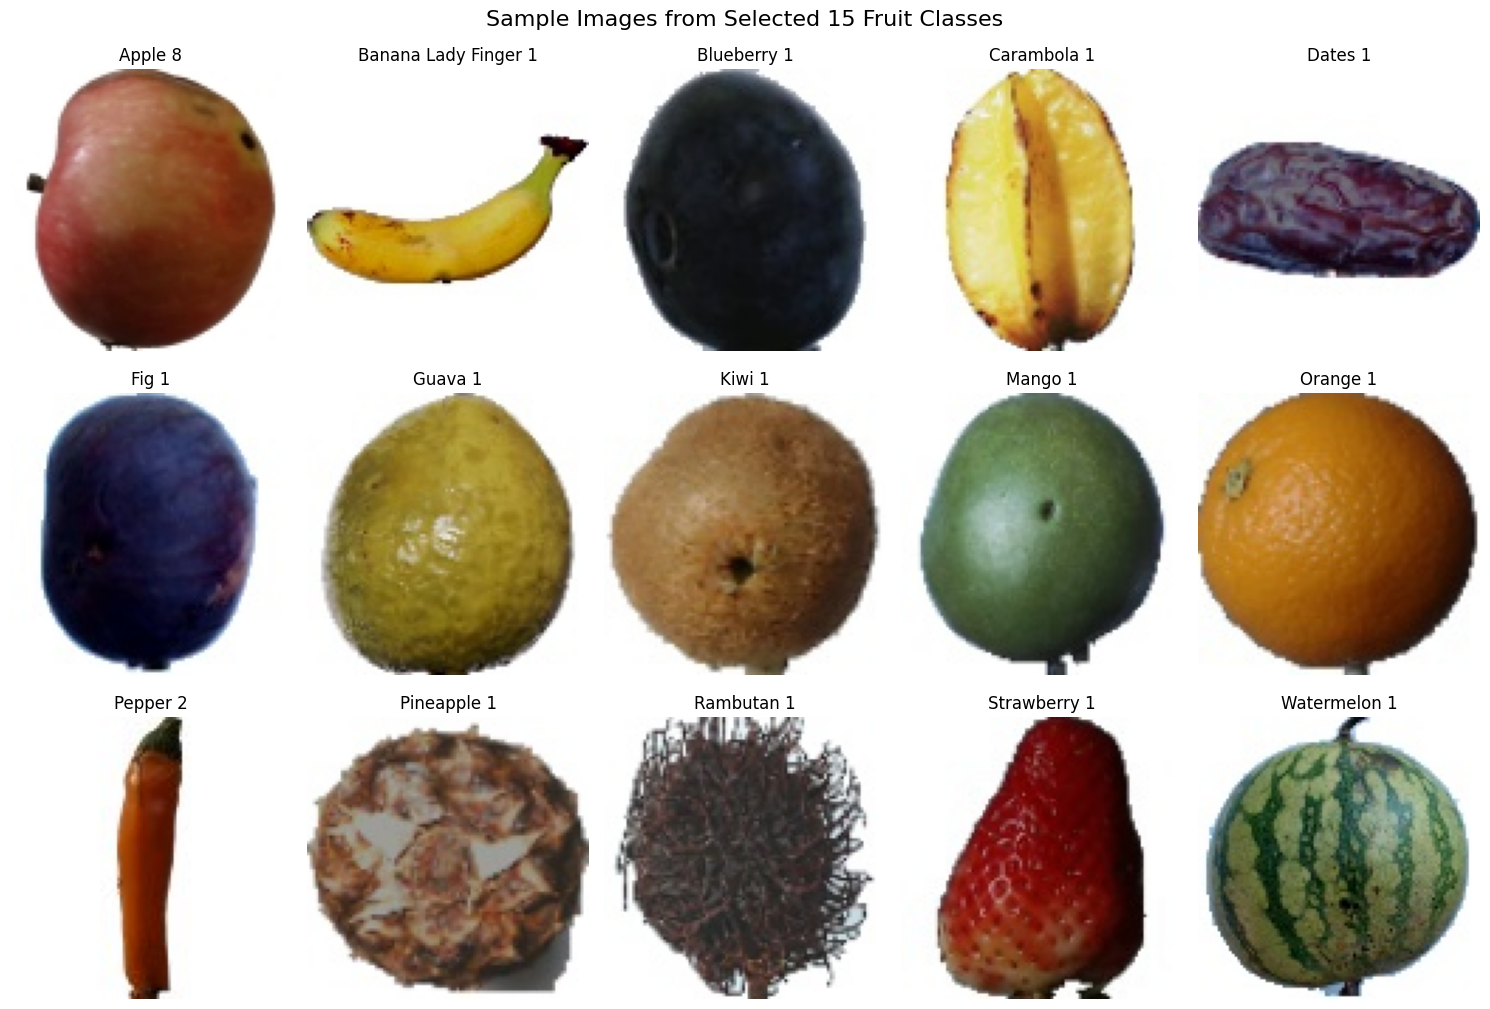

In [ ]:
import matplotlib.image as mpimg
import random

data_path = "./fruits-360/Training"
plt.figure(figsize=(15, 10))

for i, fruit in enumerate(classes):
    fruit_dir = os.path.join(data_path, fruit)
    # Pick a random image from the folder
    img_name = random.choice(os.listdir(fruit_dir))
    img_path = os.path.join(fruit_dir, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.title(fruit)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Sample Images from Selected 15 Fruit Classes", fontsize=16, y=1.02)
plt.show()


In [ ]:
import os


def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += len(
            [f for f in files if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        )
    return total


traintotal = count_images("./fruits-360/Training")
testtotal = count_images("./fruits-360/Test")
print("training images:", traintotal)
print("test images:", testtotal)

alltotal = traintotal + testtotal
print("all total: ", alltotal)


training images: 7635
test images: 2557
all total:  10192


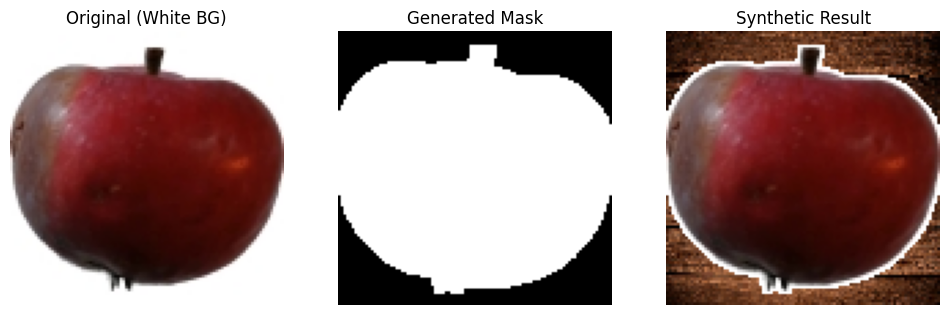

In [ ]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt


def inject_background(fruit_img_path, bg_img_path):
    # 1. Load the fruit image and the background
    # Note: Fruits-360 images are 100x100
    fruit_img = cv2.imread(fruit_img_path)
    fruit_img = cv2.cvtColor(fruit_img, cv2.COLOR_BGR2RGB)

    bg_img = cv2.imread(bg_img_path)
    bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
    bg_img = cv2.resize(bg_img, (100, 100))  # Ensure BG is same size as fruit

    # 2. Create a mask to isolate the fruit
    # Convert to grayscale to find the white background
    gray = cv2.cvtColor(fruit_img, cv2.COLOR_RGB2GRAY)

    # In Fruits-360, the background is pure white (255).
    # We create a mask where anything NOT white is 255 (the fruit).
    # Thresholding: pixels > 250 become 0 (black), others become 255 (white)
    _, mask = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    # 3. Clean up the mask (Morphological operations)
    # This removes tiny noise dots or "jagged" edges
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)

    # 4. Create the inverse mask for the background
    mask_inv = cv2.bitwise_not(mask)

    # 5. Black out the area of the fruit in the background image
    bg_with_hole = cv2.bitwise_and(bg_img, bg_img, mask=mask_inv)

    # 6. Extract only the fruit from the original image
    fruit_only = cv2.bitwise_and(fruit_img, fruit_img, mask=mask)

    # 7. Combine the two
    combined = cv2.add(fruit_only, bg_with_hole)

    return fruit_img, mask, combined


# --- EXAMPLE USAGE ---

# Paths (Update these to your actual folders)
fruit_sample = "./fruits-360/Training/Apple 8/r0_0_100.jpg"
background_sample = "./bg.avif"

if os.path.exists(fruit_sample) and os.path.exists(background_sample):
    original, mask, result = inject_background(fruit_sample, background_sample)

    # Display Results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original (White BG)")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Generated Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Synthetic Result")
    plt.imshow(result)
    plt.axis("off")

    plt.show()
else:
    print("Please ensure your file paths are correct.")


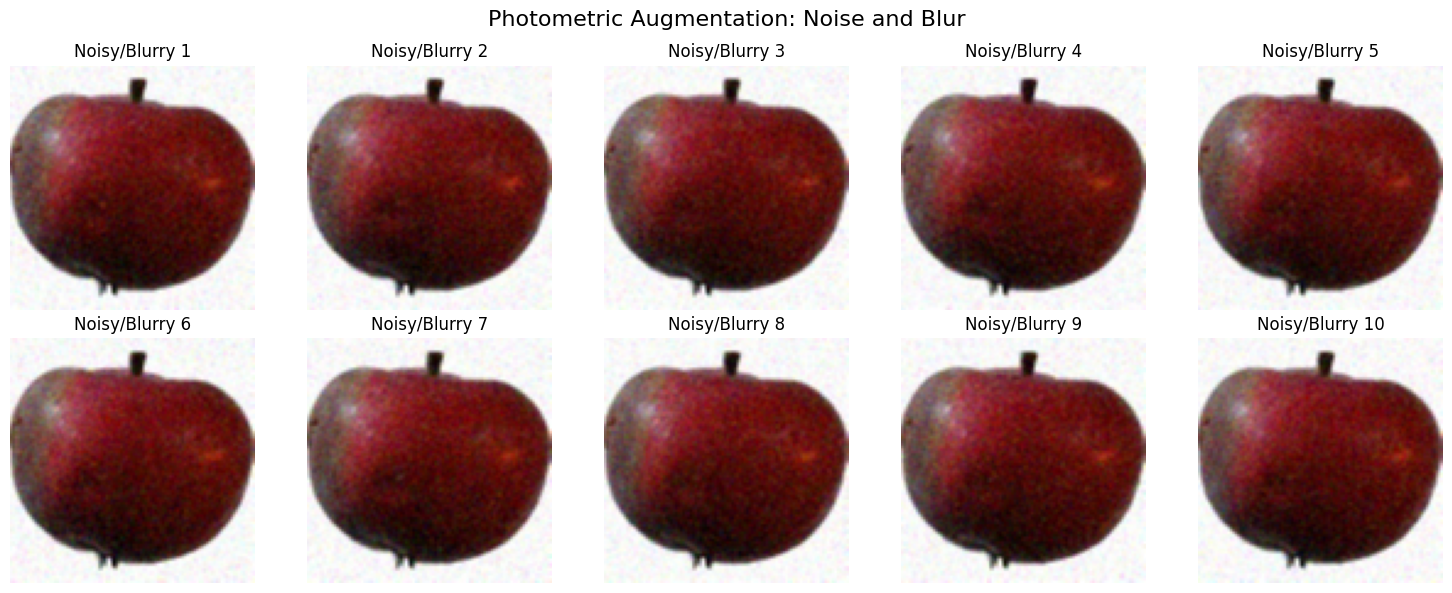

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


def apply_noise_and_blur(img_tensor):
    # 1. Add Gaussian Noise
    # This simulates sensor grain. We add random values and clip to keep pixels in [0, 255]
    noise = tf.random.normal(
        shape=tf.shape(img_tensor), mean=0.0, stddev=15.0, dtype=tf.float32
    )
    noisy_img = tf.add(img_tensor, noise)
    noisy_img = tf.clip_by_value(noisy_img, 0.0, 255.0)

    # 2. Add Gaussian Blur
    # This simulates a camera that is slightly out of focus
    # Note: We use a simple uniform filter here for visualization
    # In a real pipeline, you can use tfa.image.gaussian_filter2d
    blur_layer = tf.keras.layers.AvgPool2D(pool_size=(2, 2), strides=1, padding="same")
    blurred_img = blur_layer(noisy_img)

    return blurred_img


# --- Visualization ---

# Load sample
sample_path = "./fruits-360/Training/Apple 8/r0_0_100.jpg"
img = tf.keras.utils.load_img(sample_path)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch

plt.figure(figsize=(15, 6))
plt.suptitle("Photometric Augmentation: Noise and Blur", fontsize=16)

for i in range(10):
    # Apply noise and blur
    processed_img = apply_noise_and_blur(img_array)

    plt.subplot(2, 5, i + 1)
    plt.imshow(processed_img[0].numpy().astype("uint8"))
    plt.title(f"Noisy/Blurry {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


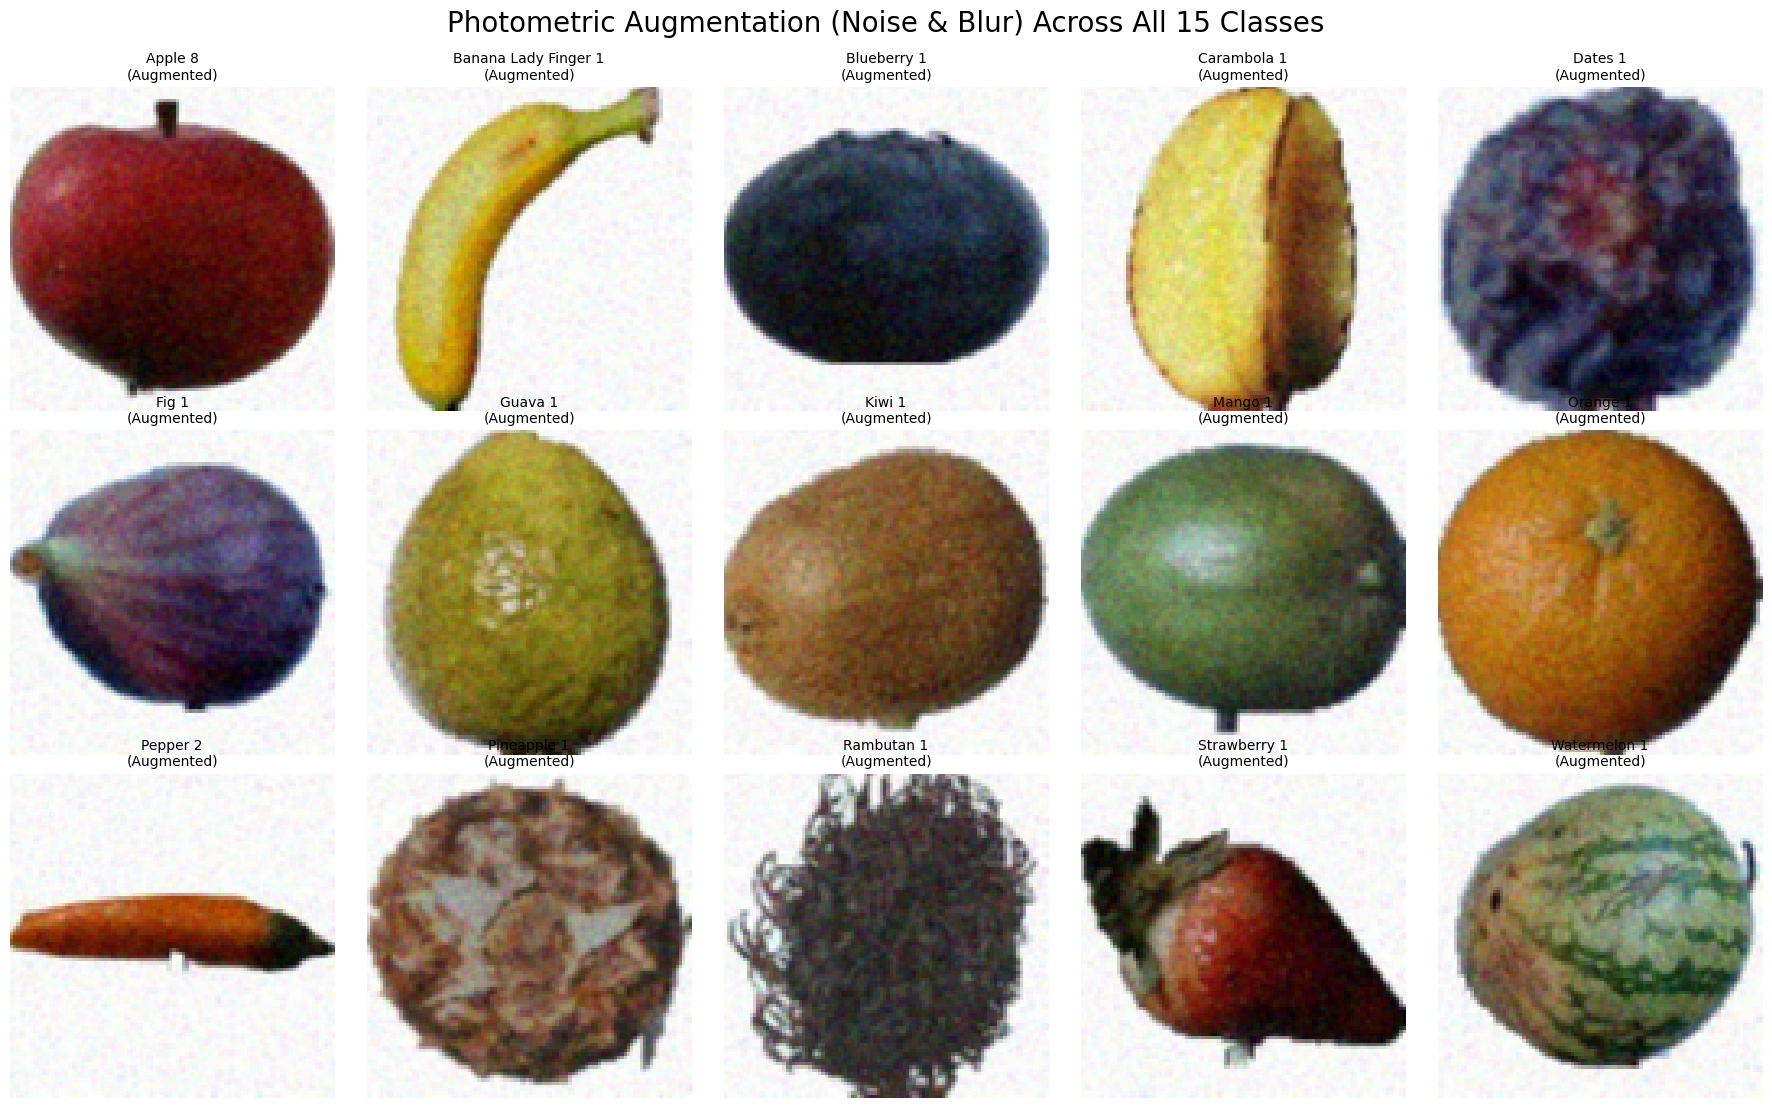

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# 1. Reuse your noise and blur function
def apply_noise_and_blur(img_tensor):
    # Add Gaussian Noise
    noise = tf.random.normal(
        shape=tf.shape(img_tensor), mean=0.0, stddev=15.0, dtype=tf.float32
    )
    noisy_img = tf.add(img_tensor, noise)
    noisy_img = tf.clip_by_value(noisy_img, 0.0, 255.0)

    # Add Gaussian Blur (Simulating focus issues)
    blur_layer = tf.keras.layers.AvgPool2D(pool_size=(2, 2), strides=1, padding="same")
    blurred_img = blur_layer(noisy_img)

    return blurred_img


# 2. Setup paths and classes
data_path = "./fruits-360/Training"
classes = [
    "Apple 8",
    "Banana Lady Finger 1",
    "Blueberry 1",
    "Carambola 1",
    "Dates 1",
    "Fig 1",
    "Guava 1",
    "Kiwi 1",
    "Mango 1",
    "Orange 1",
    "Pepper 2",
    "Pineapple 1",
    "Rambutan 1",
    "Strawberry 1",
    "Watermelon 1",
]

# 3. Visualization: 1 picture from each of the 15 classes with noise applied
plt.figure(figsize=(18, 12))
plt.suptitle(
    "Photometric Augmentation (Noise & Blur) Across All 15 Classes", fontsize=20, y=0.95
)

for i, fruit in enumerate(classes):
    # Path to a random image in the fruit folder
    fruit_dir = os.path.join(data_path, fruit)
    img_name = random.choice(os.listdir(fruit_dir))
    img_path = os.path.join(fruit_dir, img_name)

    # Load and convert to tensor for the function
    img = tf.keras.utils.load_img(img_path, target_size=(100, 100))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch

    # Apply the noise/blur function
    processed_img = apply_noise_and_blur(img_array)

    # Plotting in a 3x5 grid
    plt.subplot(3, 5, i + 1)
    # Convert back to uint8 for display
    plt.imshow(processed_img[0].numpy().astype("uint8"))
    plt.title(f"{fruit}\n(Augmented)", fontsize=10)
    plt.axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


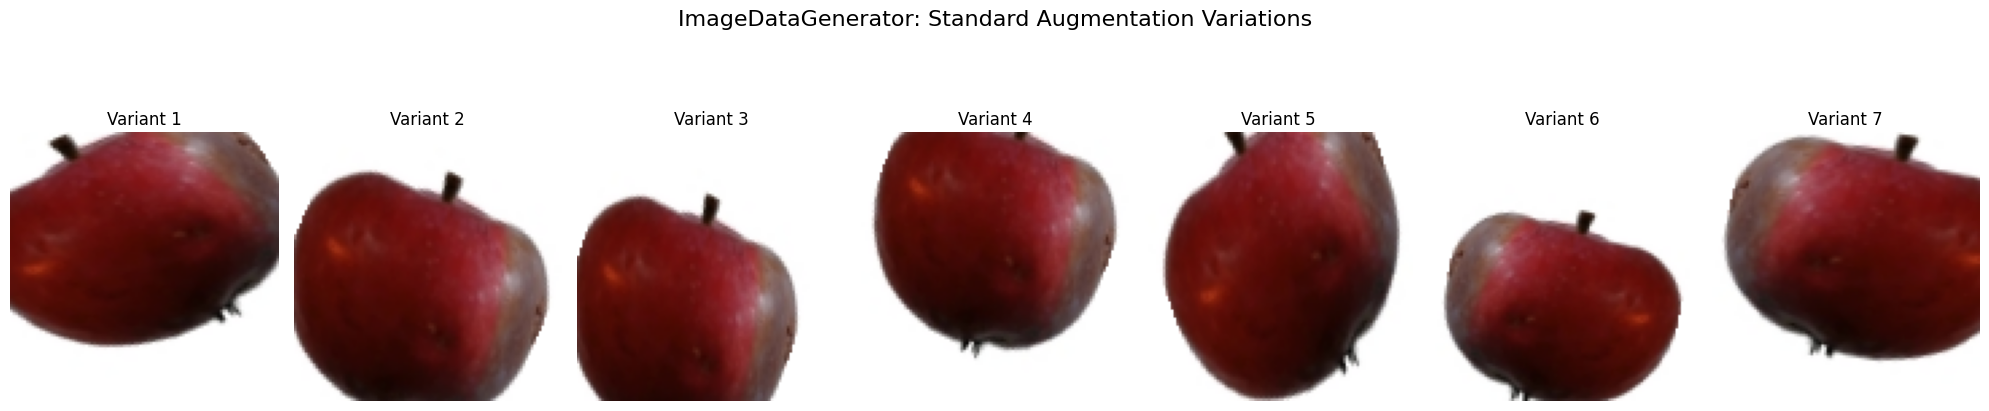

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Data Augmentation Pipeline
# Tailored for Fruits-360 (Note the white background fill)
datagen = ImageDataGenerator(
    rotation_range=30,  # Rotate images by up to 30 degrees
    width_shift_range=0.2,  # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Zoom in/out by 20%
    horizontal_flip=True,  # Flip images horizontally
    fill_mode="constant",  # Keep background clean
    cval=255.0,  # Fill missing pixels with White (important for fruits-360)
)

# 2. Load an example image
# Replace with a valid path from your subset folders
sample_path = "./fruits-360/Training/Apple 8/r0_0_100.jpg"

if os.path.exists(sample_path):
    img = image.load_img(sample_path, target_size=(100, 100))
    x = image.img_to_array(img)  # Convert to NumPy array
    x = np.expand_dims(x, axis=0)  # Add batch dimension (1, 100, 100, 3)

    # 3. Generate augmented images
    # flow() generates batches of augmented data
    aug_iter = datagen.flow(x, batch_size=1)

    # 4. Visualize 7 augmented images
    fig, ax = plt.subplots(1, 7, figsize=(20, 5))
    fig.suptitle("ImageDataGenerator: Standard Augmentation Variations", fontsize=16)

    for i in range(7):
        batch = next(aug_iter)
        # Convert to uint8 for proper visualization
        ax[i].imshow(batch[0].astype("uint8"))
        ax[i].set_title(f"Variant {i+1}")
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"File not found at {sample_path}. Please check your directory structure.")
